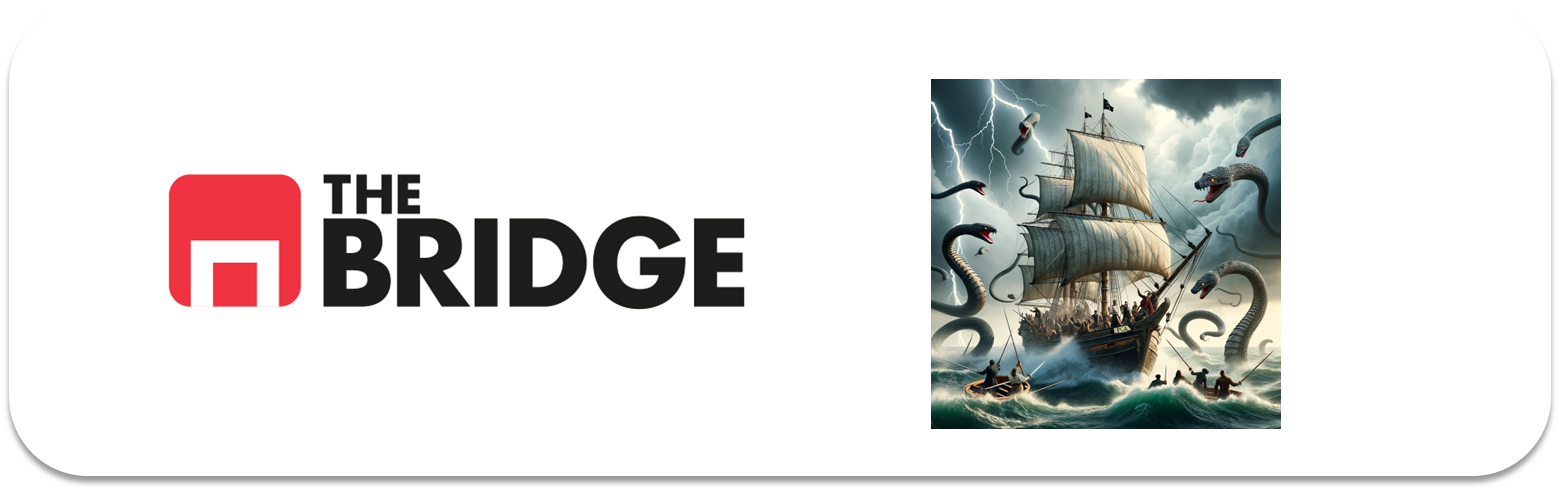

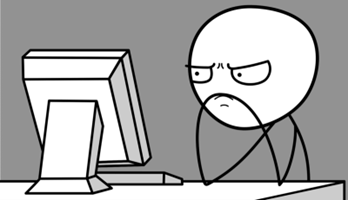

Para ejercitarte y afianzar lo aprendido sobre **Seleccion de Features**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

## Feature selection: Breast Cancer Winsconsin

El objetivo de este grupo de ejercicio es dar a entender la importancia de la selección de características (features), así como probar distintos métodos de reducción de características (features) y qué influencia puede tener el reducir features en el perfomance de un modelo. Nuestro target para evaluar el perfomance será si estamos ante tumores malignos o benignos.

Vamos a trabajar con el dataset de Breast Cancer Winsconsin, datos tomados a partir de radiografías.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np

### Ejercicio 1:

Carga los datos y haz una primera inspección de los mismos y comenta lo que creas conveniente sobre las features y su relación entre sí (pero sin analizarlas numéricamente)

In [2]:
df = pd.read_csv("./data/breastcancer-winsconsin.csv")
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

### Ejercicio 2:

Descarta las características que evidentemente no aportan información.

In [3]:
def describe_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Genera un resumen estadístico descriptivo de un DataFrame.

    Argumentos:
        df (pd.DataFrame): DataFrame a analizar.

    Retorna:
        pd.DataFrame: DataFrame con una fila por columna del input y las
        siguientes columnas: 'tipo', 'porcentaje_nulos', 'valores_unicos',
        'porcentaje_cardinalidad'.
        Retorna None si el input no es un DataFrame válido.
    """
    
    # Comprobación de que si es un DataFrame
    if not isinstance(df, pd.DataFrame):
        print("Error: el objeto proporcionado no es un DataFrame.")
        return None

    # Crear el DataFrame resultado
    resultado = pd.DataFrame(index=df.columns)

    # Tipo de dato
    resultado["tipo"] = df.dtypes.astype(str)

    # Porcentaje de nulos
    resultado["porcentaje_nulos"] = (df.isna().mean() * 100).round(2)

    # Valores únicos
    resultado["valores_unicos"] = df.nunique()

    # Porcentaje de cardinalidad
    resultado["porcentaje_cardinalidad"] = ((df.nunique() / len(df)) * 100).round(2)


    return resultado

In [4]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
id,int64,0.0,569,100.00
diagnosis,str,0.0,2,0.35
radius_mean,float64,0.0,456,80.14
texture_mean,float64,0.0,479,84.18
perimeter_mean,float64,0.0,522,91.74
area_mean,float64,0.0,539,94.73
smoothness_mean,float64,0.0,474,83.30
compactness_mean,float64,0.0,537,94.38
concavity_mean,float64,0.0,537,94.38
concave points_mean,float64,0.0,542,95.25


In [5]:
df = df.drop(columns=["id", "Unnamed: 32"])

<Axes: >

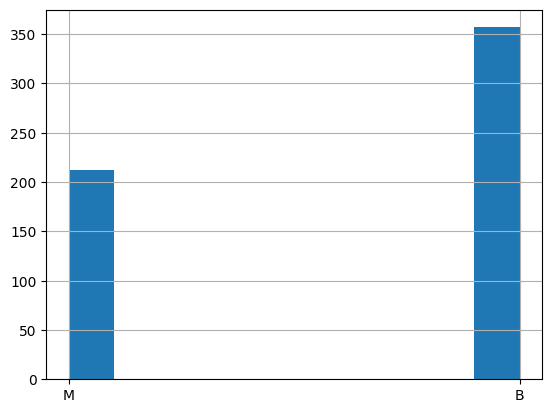

In [6]:
df.diagnosis.hist()

### Ejercicio 3: 

Divide en train y test. Analiza el target de forma breve.

In [ ]:
# como es un target desbalanceado, stratify = target

In [7]:
from sklearn.model_selection import train_test_split

TARGET = 'diagnosis'  # ← Cambia esto por el nombre de tu columna objetivo

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20 % para test
    random_state=42,     # Fija la semilla → resultados reproducibles
    stratify=y         # Descomentar en clasificación con clases desbalanceadas
)

print(f"Train: {X_train.shape[0]} filas  ({X_train.shape[0]/len(df)*100:.0f} %)")
print(f"Test:  {X_test.shape[0]} filas  ({X_test.shape[0]/len(df)*100:.0f} %)")

Train: 455 filas  (80 %)
Test:  114 filas  (20 %)


### Ejercicio 4: MiniEDA (I) Análisis Visual

Realiza un análisis visual de las features y haz tu selección de primera "división" (que luego usaremos para comparar con otros métodos de selección).

In [18]:
from bootcampviztools import plot_grouped_histograms

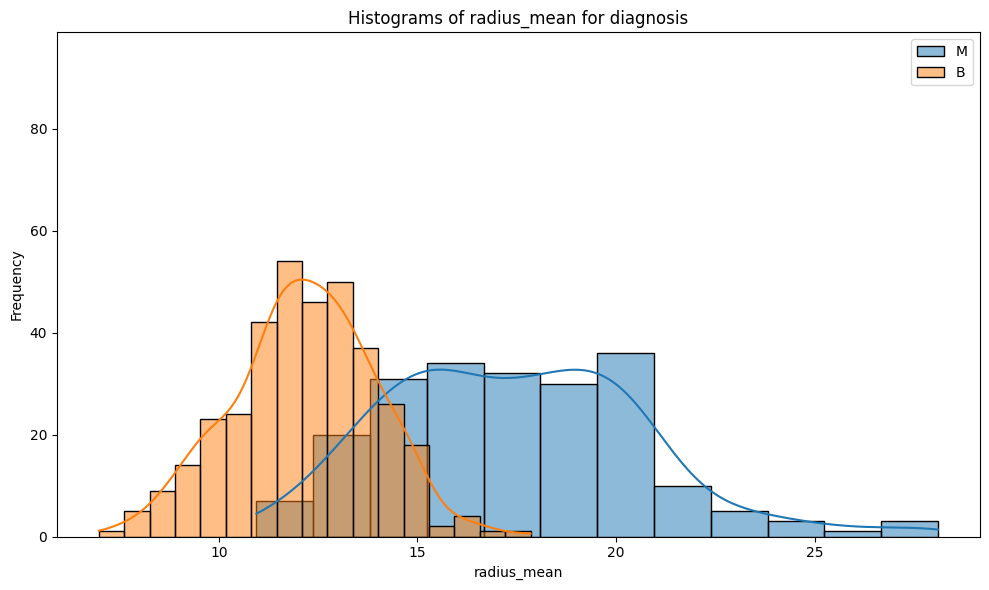

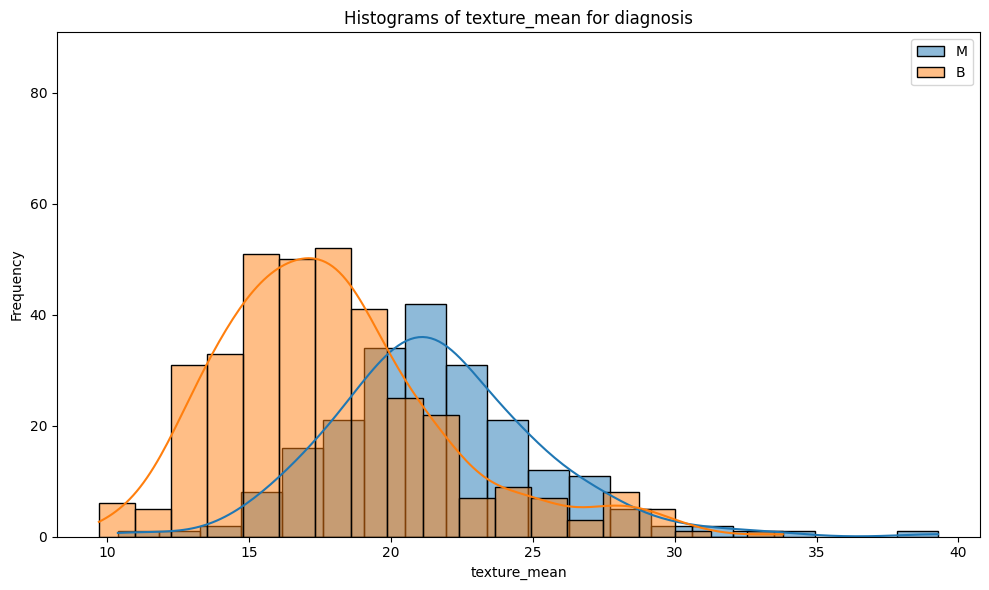

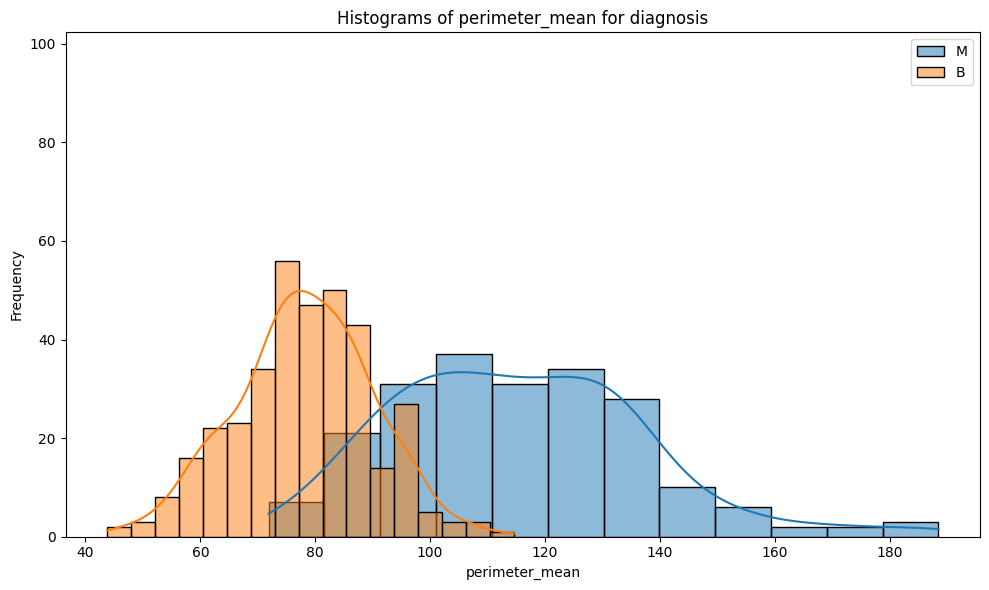

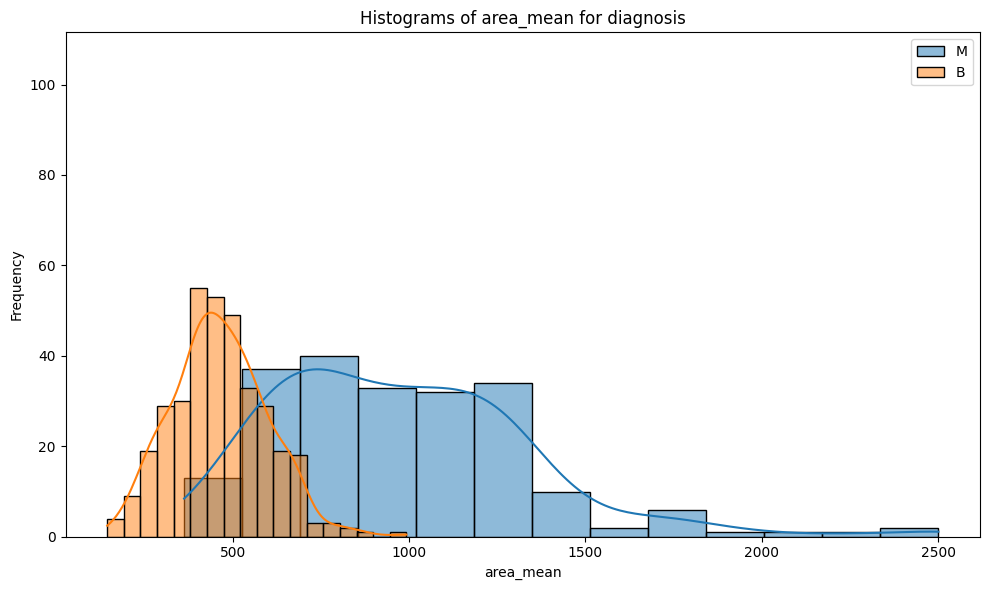

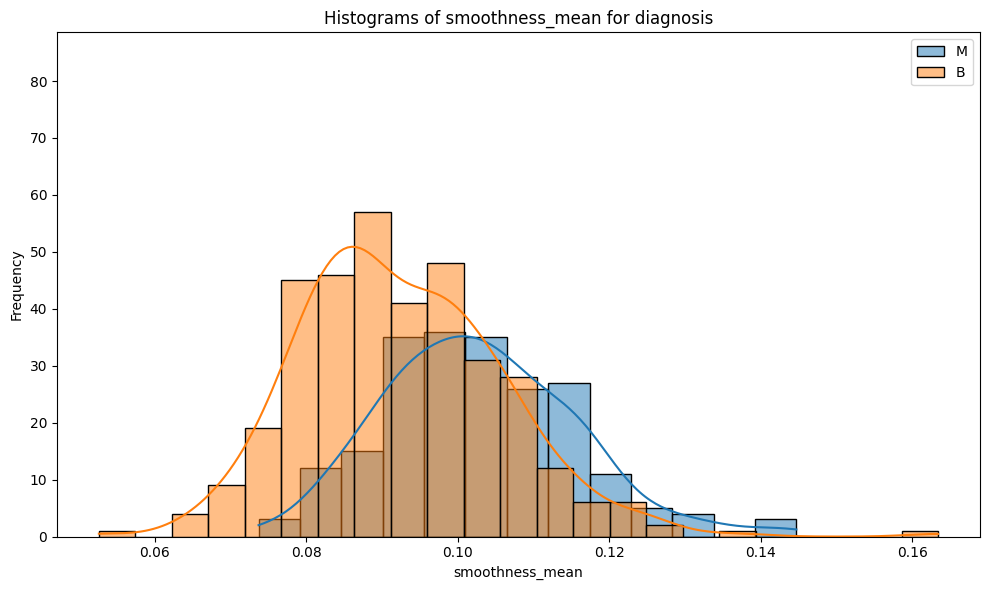

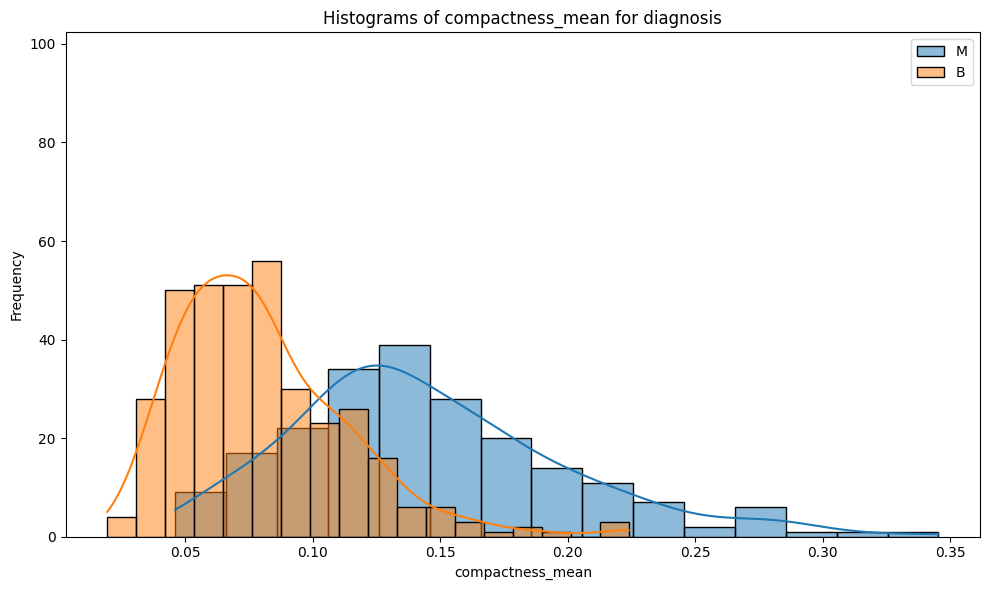

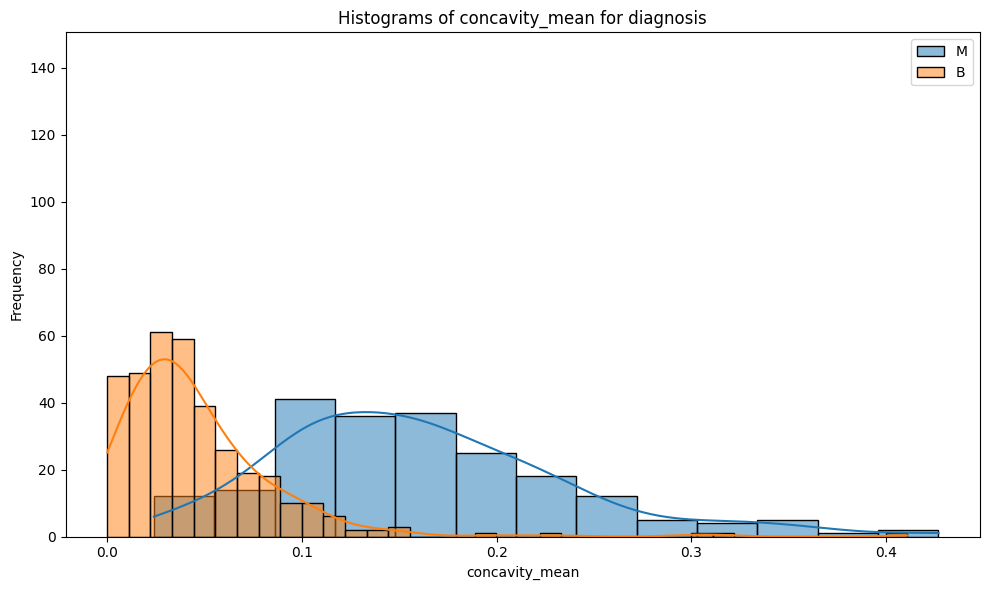

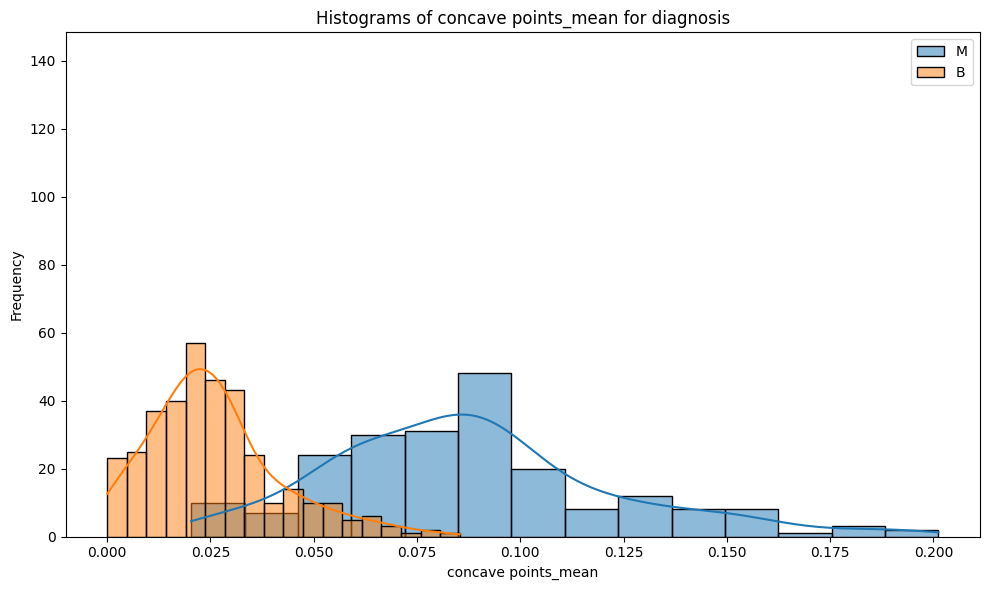

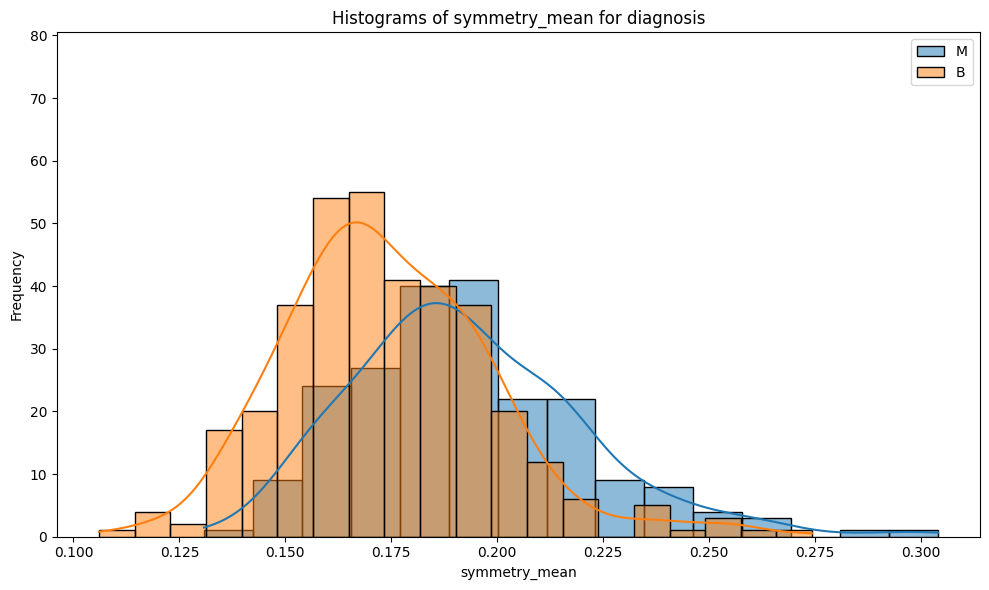

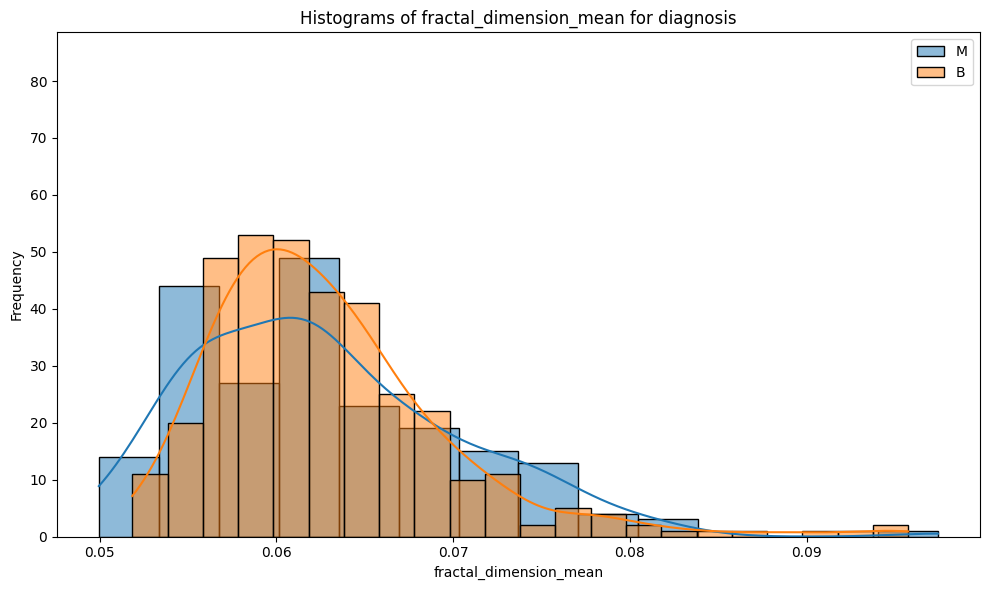

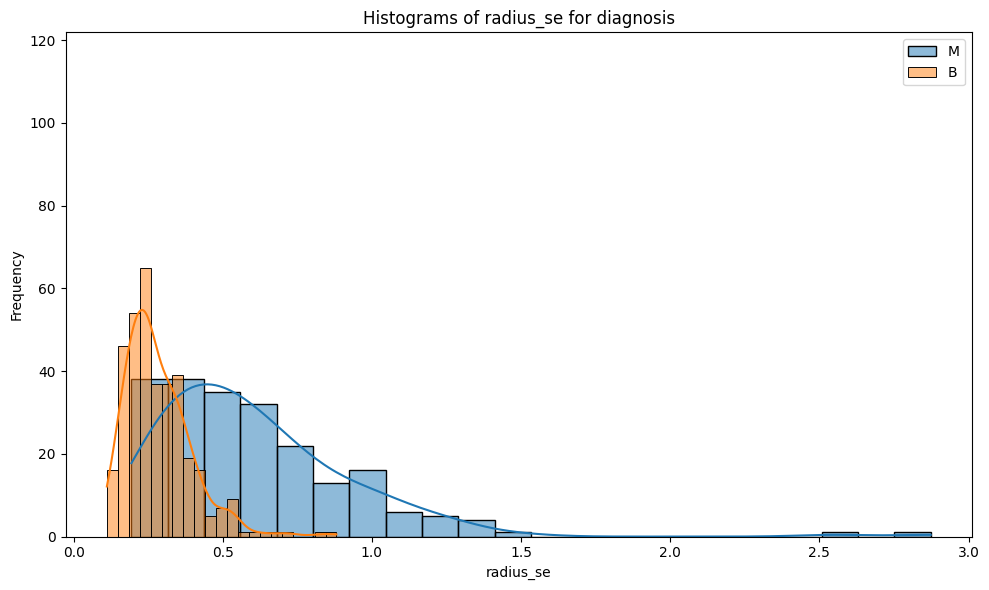

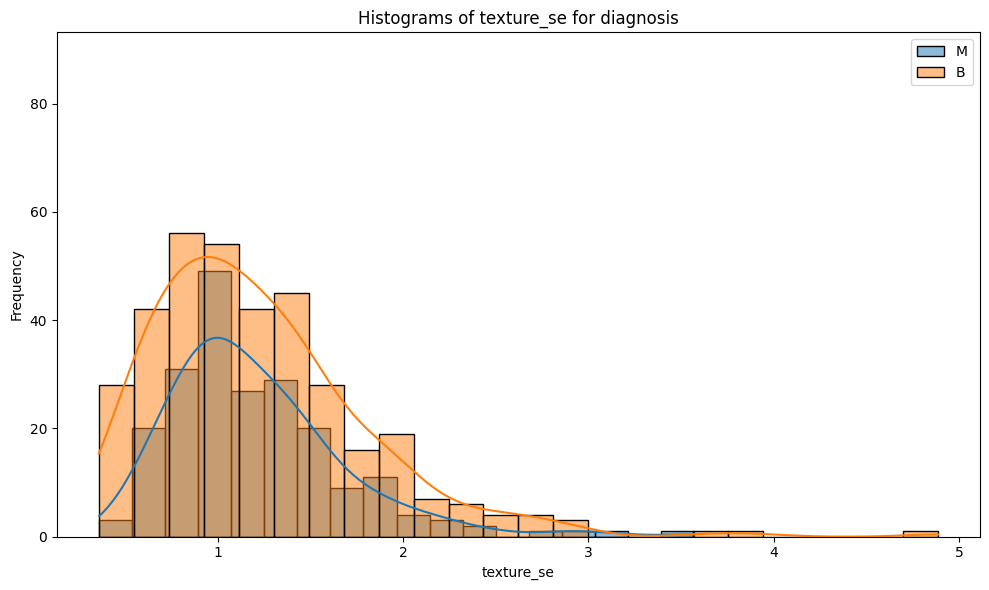

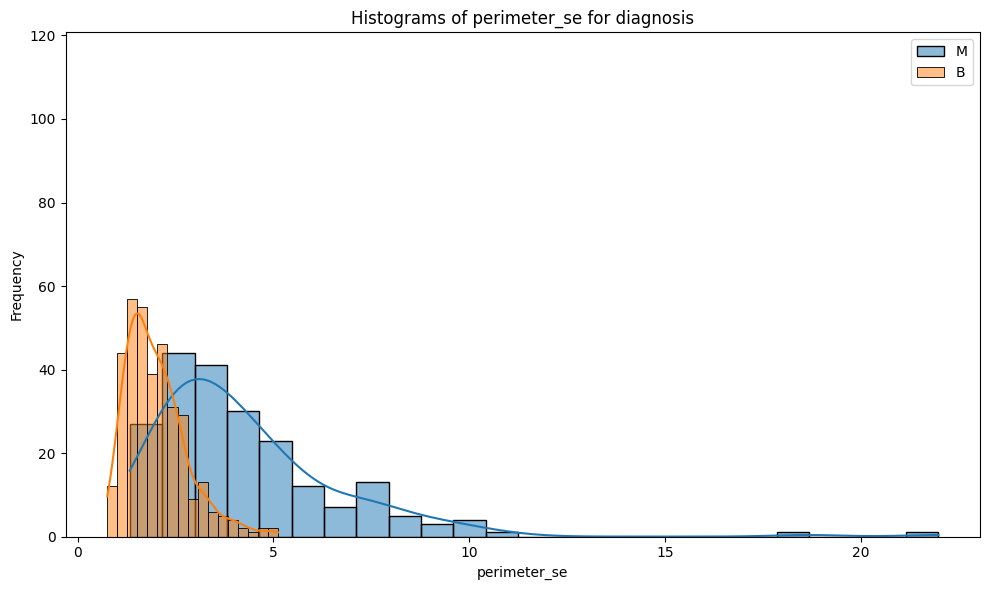

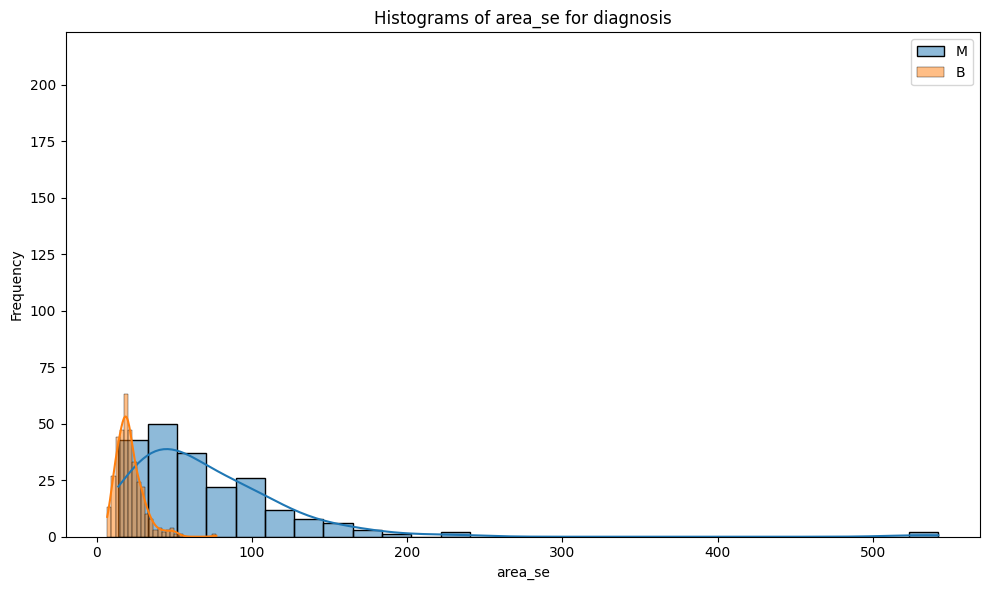

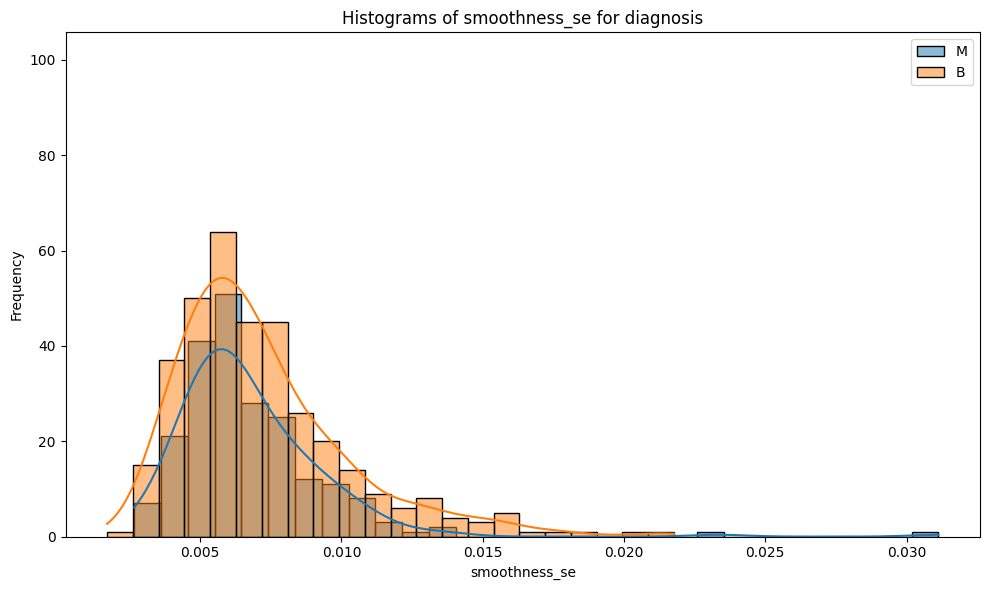

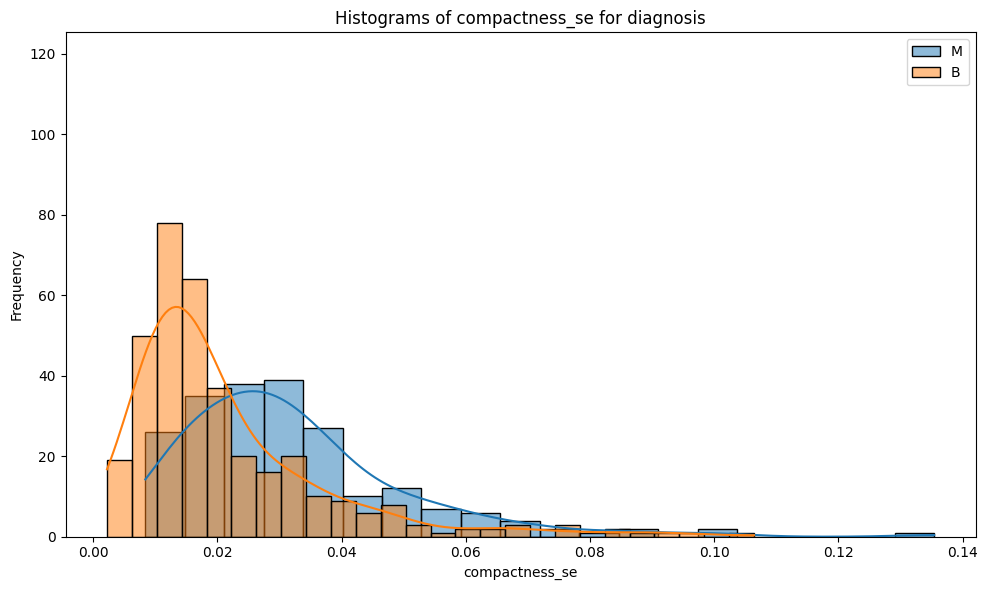

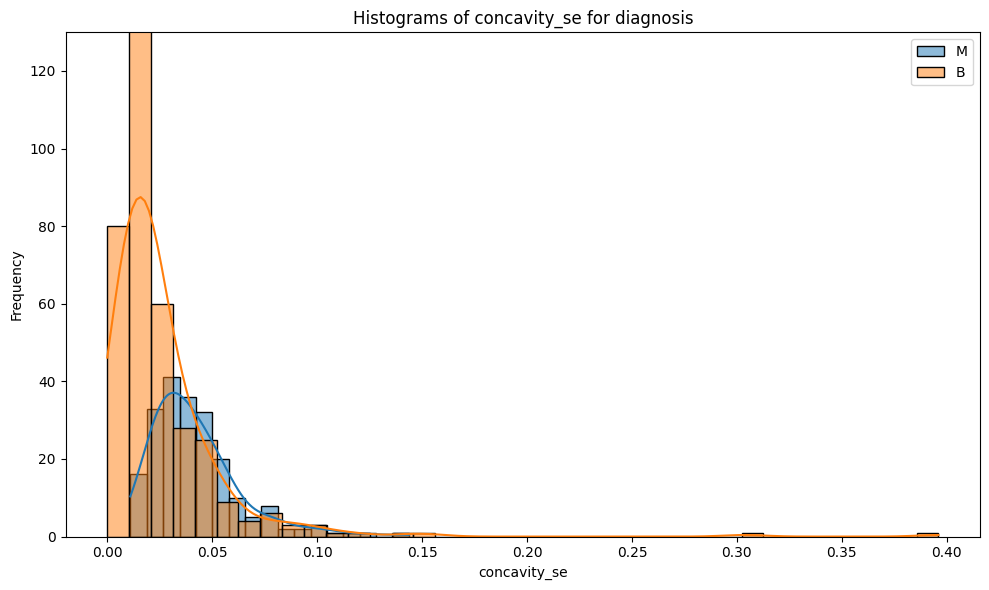

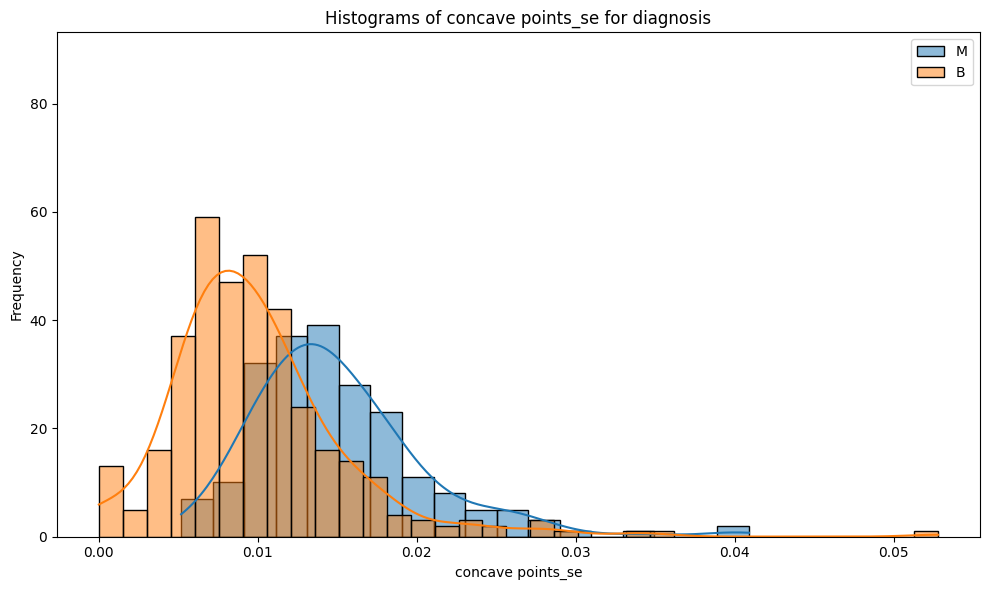

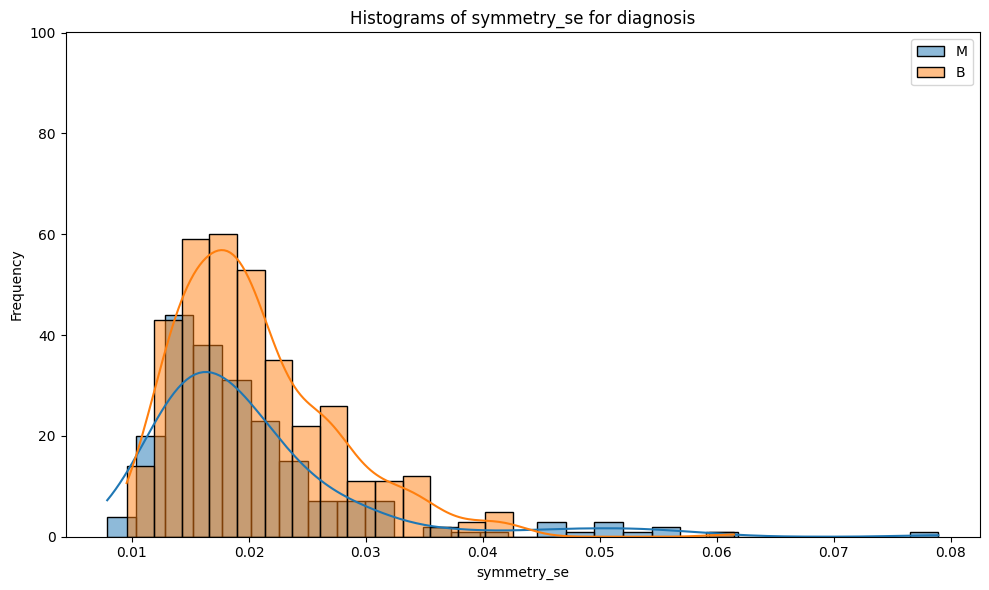

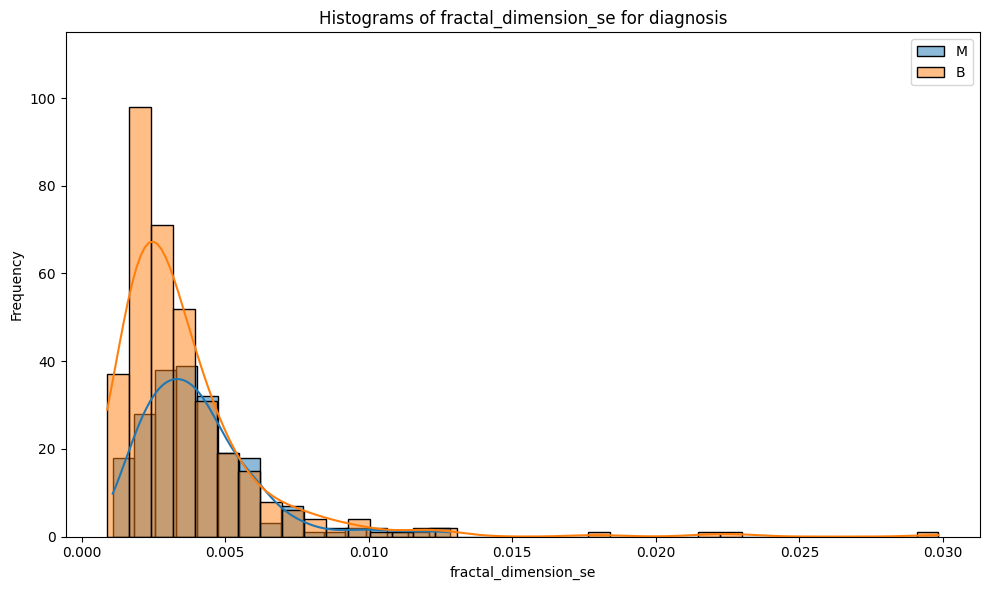

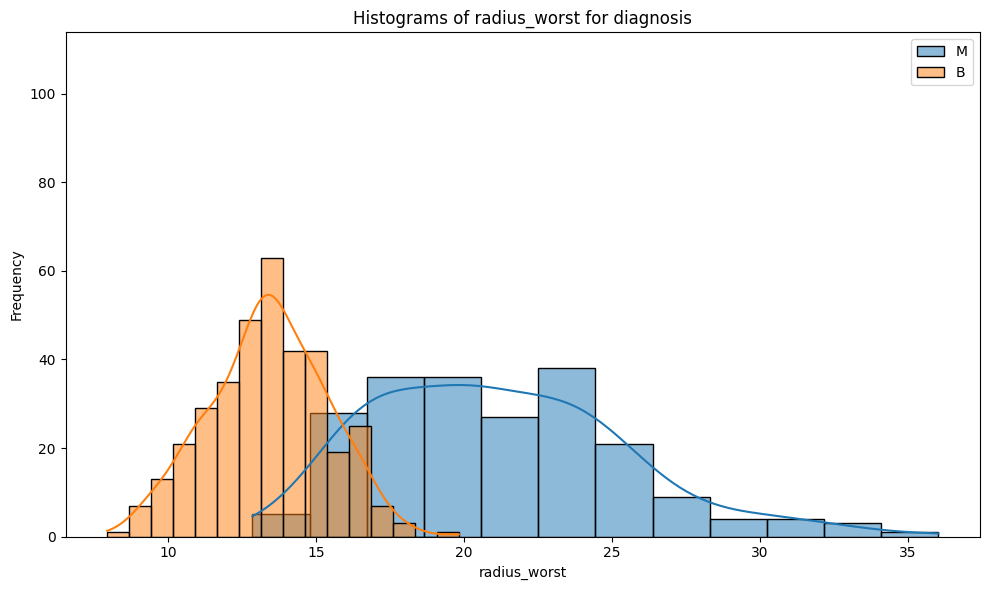

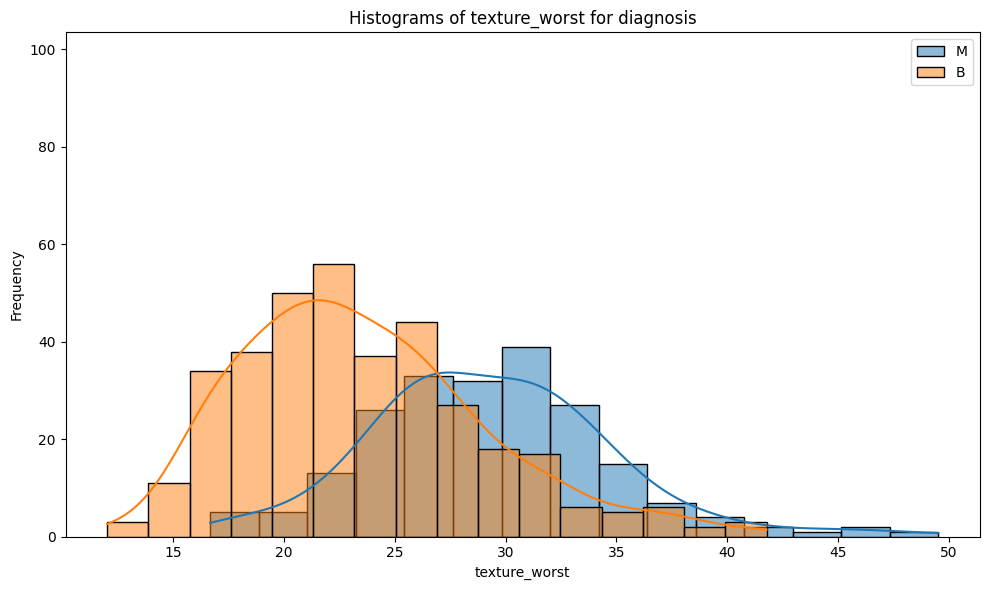

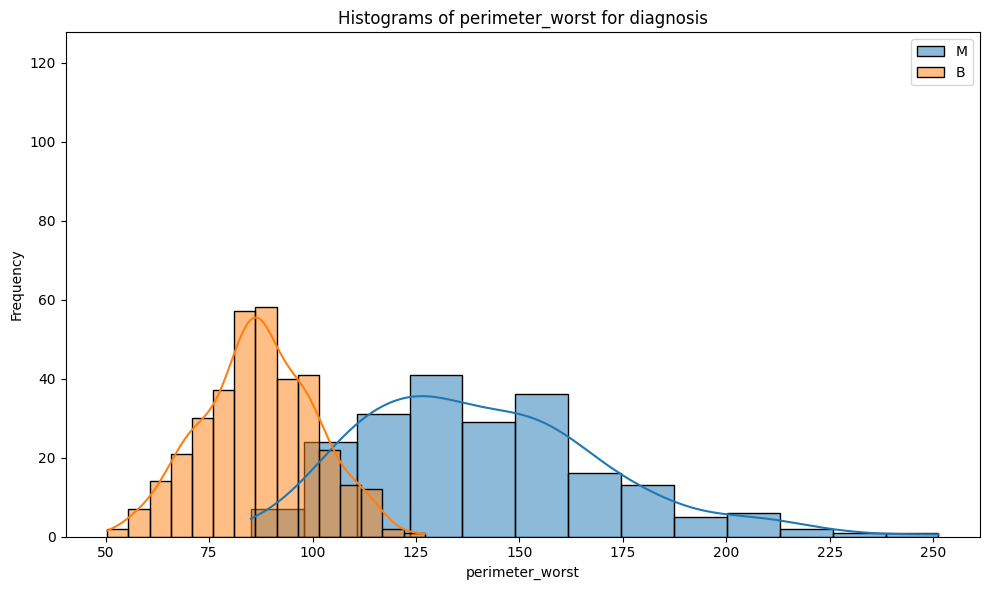

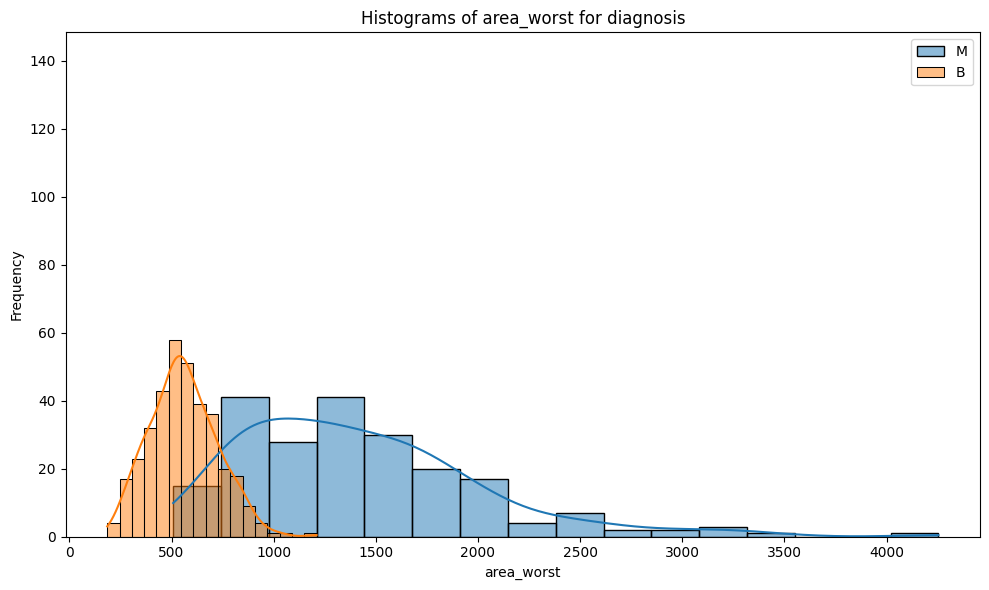

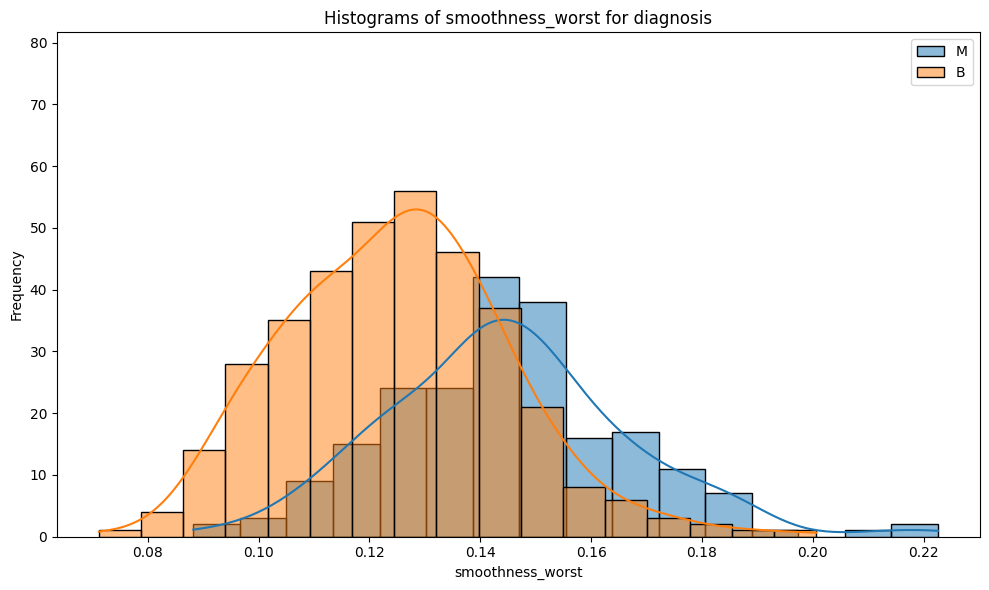

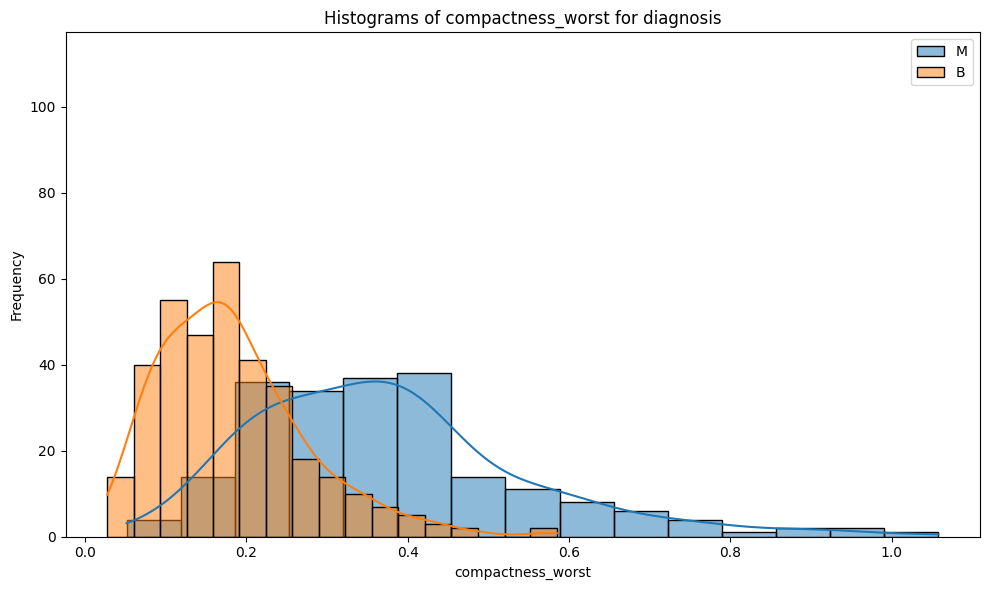

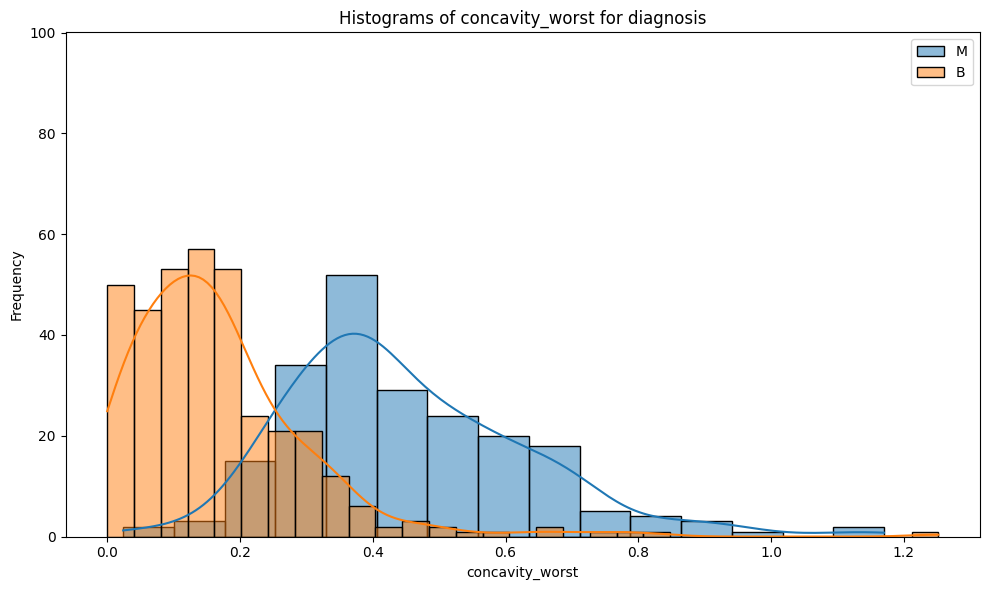

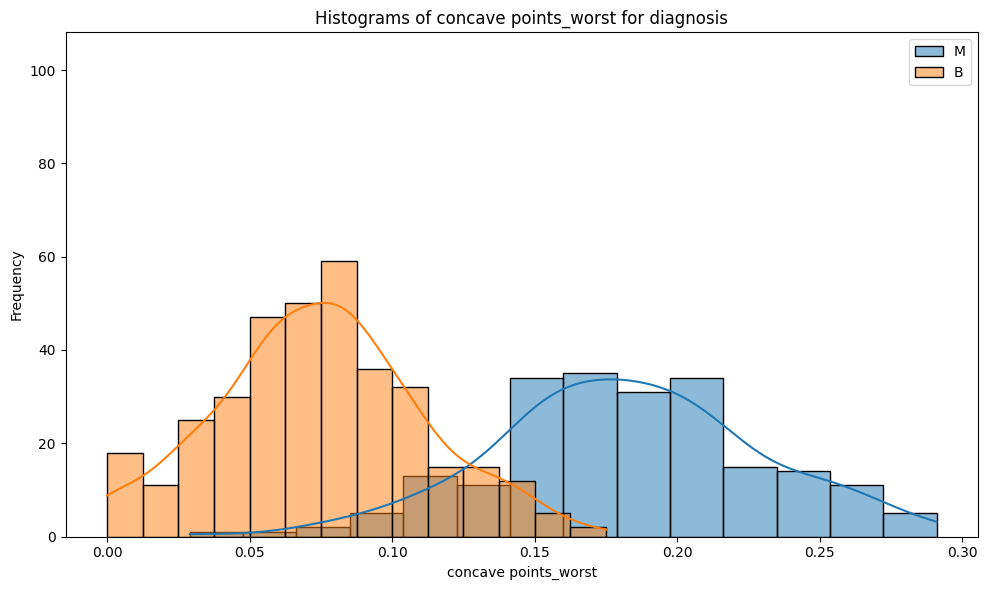

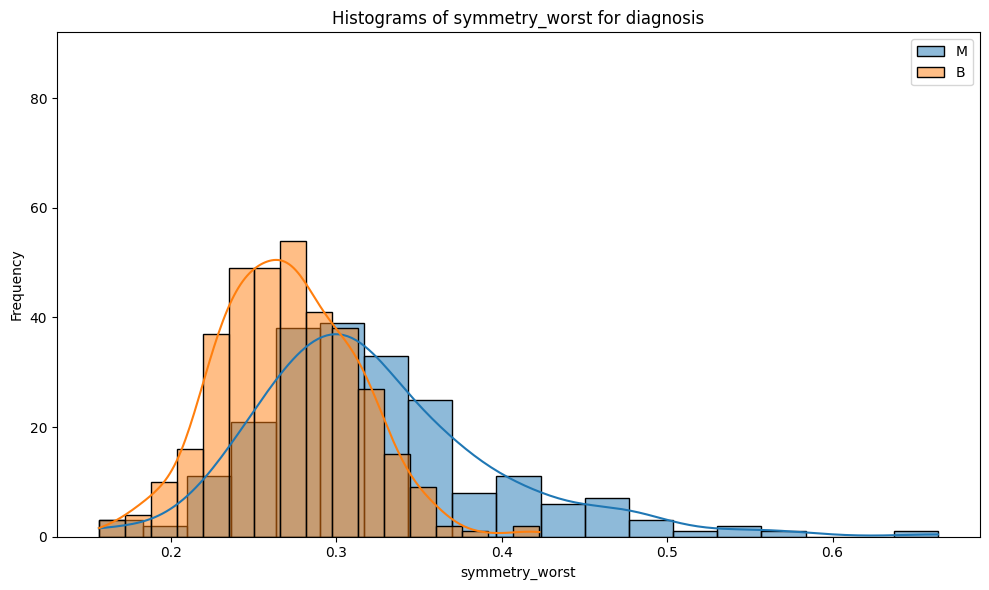

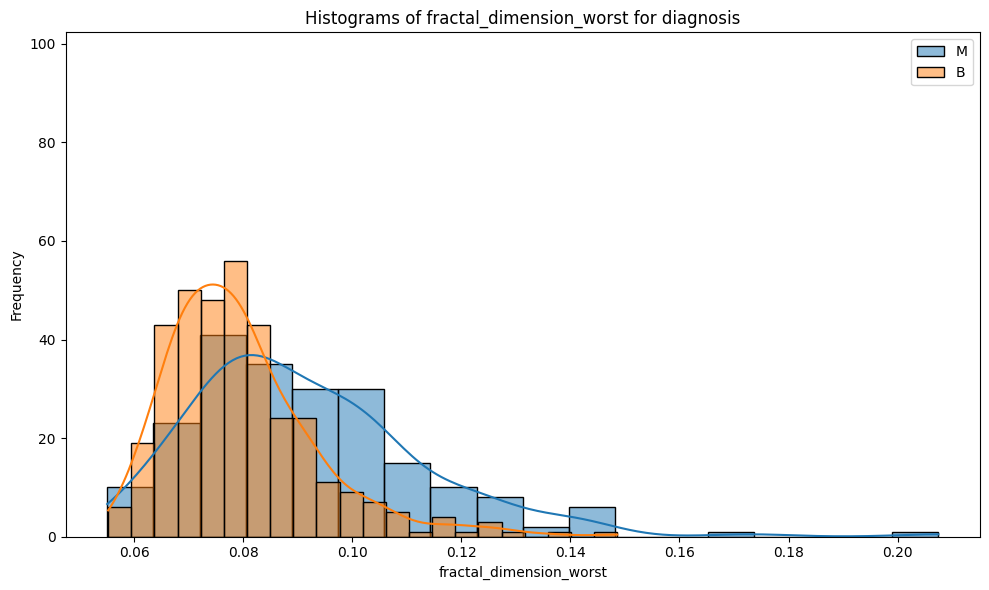

In [26]:
num_cols = X_train.select_dtypes(include=["number"]).columns

for col in num_cols:
    plot_grouped_histograms(df, cat_col="diagnosis", num_col=col)


In [29]:
features_primera_visual = ["convave points_worst", "concavity_worst", "compactness_worst", "area_worst", "radious_worst", "area_se", "perimeter_se", "radius_se", "concave points_mean", "concavity_mean", "area_mean", "perimeter_mean", "radius_mean"]
features_segunda_visual = ["fractal_dimension_se", "symmetry_se", "smoothness_se", "fractal_dimension_worst", "symmetry_worst", "smoothness_worst", "texture_worst", "concave points_se", "concavity_se", "compactness_se", "texture_se", "fractal_dimension_mean", "symmetry_mean", "smoothness_mean", "texture_mean"]


In [28]:
X_train.columns

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

### Ejercicio 5

Observa correlaciones entre las features. Utiliza un gráfico apropiado para ello. ¿Crees que sea posible eliminar algunas features para mejorar el modelo? (No hace falta que lo hagas ahora, lo haremos si es necesario en un ejercicio posterior)

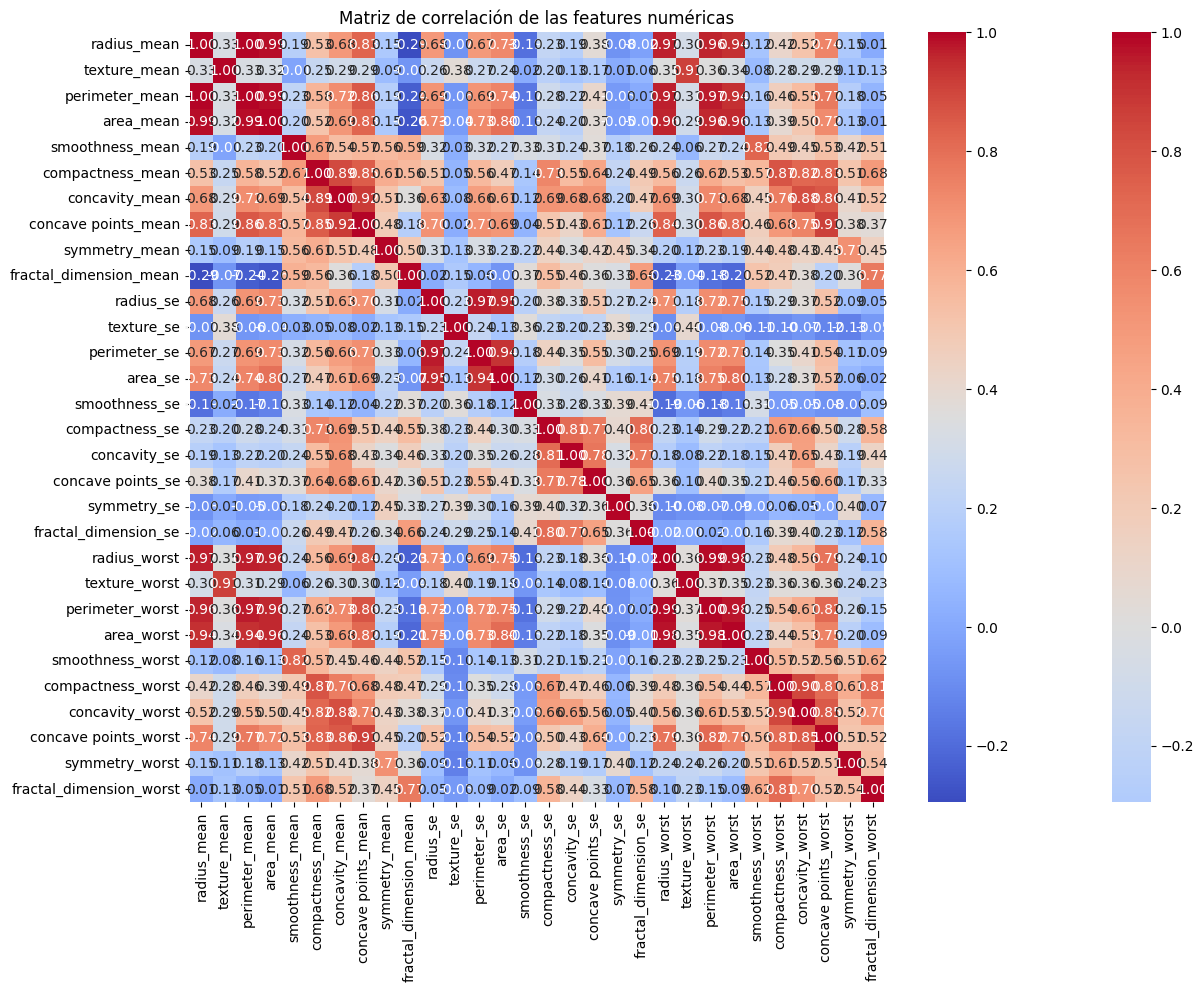

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))
sns.heatmap(
    X_train.corr(),
    cmap="coolwarm",
    annot=False,
    center=0
)
sns.heatmap(X_train.corr(), cmap="coolwarm", annot=True, fmt=".2f")

plt.title("Matriz de correlación de las features numéricas")
plt.show()


### Ejercicio 6:

Entrena (con validación cruzada) un modelo de RandomForestClassifier (con max_depth a 5) con todas las features (ojo incluso las que descartamos en el ejercicio 4) y guarda el perfomance ("balanced_accuracy") en test en una variable. Será nuestro base line de comparación

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf_base = RandomForestClassifier(max_depth=5, random_state=42)

scores = cross_val_score(
    rf_base,
    X_train,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

print("Balanced Accuracy CV (train):", scores.mean())


Balanced Accuracy CV (train): 0.9506707946336428


### Ejercicio 7

Vamos a emplear nuestras features del análisis visual pero descartando variables correladas entre sí (emplea la matriz ya obtenida en el ejercicio 5 o bien cualquier medio que creas conveniente). Descarta features y muestra la matriz de correlación para la selección final (recuerda, parte de la lista creada en el ejercicio 4)

In [35]:
features_primera_visual = [
    "concave points_worst", "concavity_worst", "compactness_worst",
    "area_worst", "radius_worst", "area_se", "perimeter_se", "radius_se",
    "concave points_mean", "concavity_mean", "area_mean", "perimeter_mean", "radius_mean"
]

features_segunda_visual = [
    "fractal_dimension_se", "symmetry_se", "smoothness_se", "fractal_dimension_worst",
    "symmetry_worst", "smoothness_worst", "texture_worst", "concave points_se",
    "concavity_se", "compactness_se", "texture_se", "fractal_dimension_mean",
    "symmetry_mean", "smoothness_mean", "texture_mean"
]


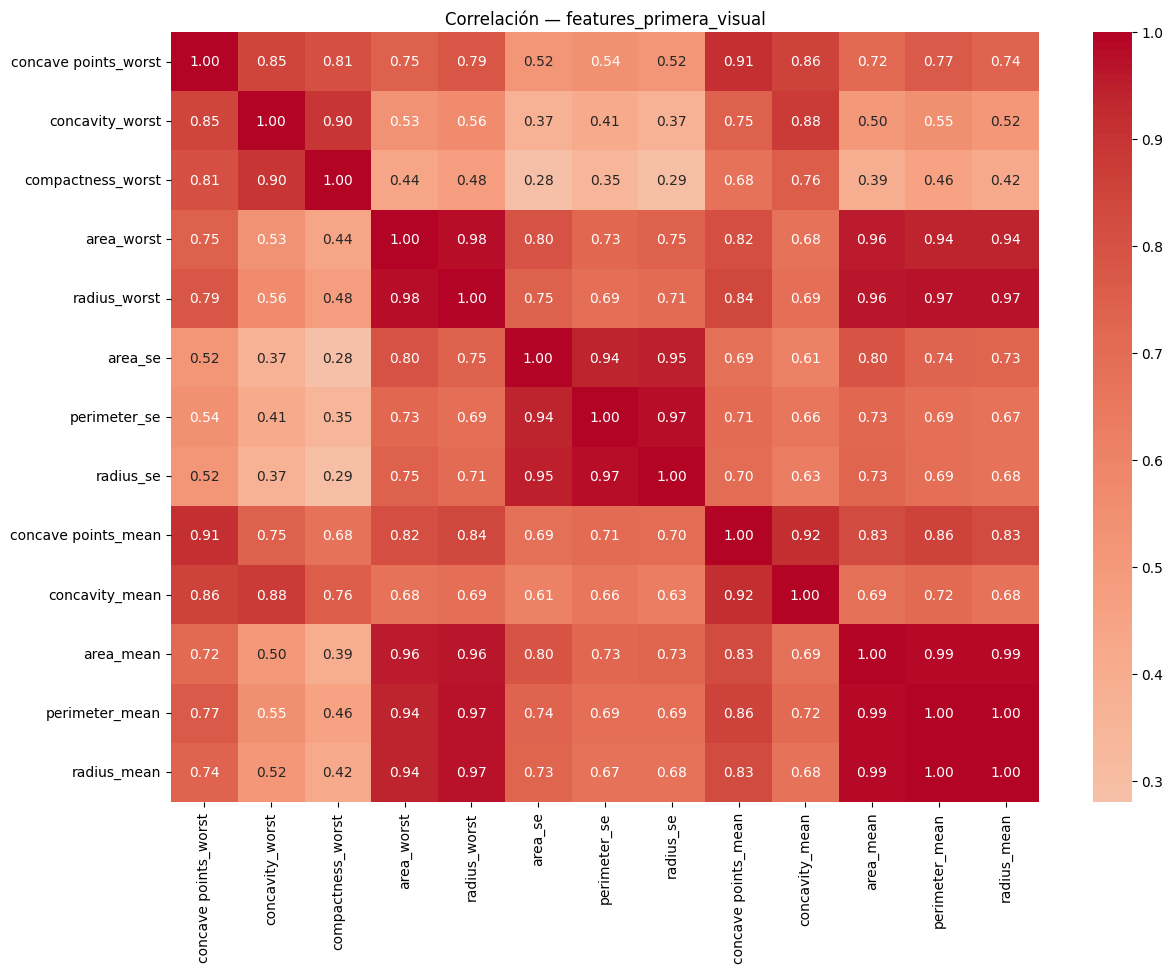

In [36]:
plt.figure(figsize=(14,10))
sns.heatmap(
    X_train[features_primera_visual].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    center=0
)
plt.title("Correlación — features_primera_visual")
plt.show()


In [37]:
import numpy as np

def remove_correlated(df, features, threshold=0.85):
    corr = df[features].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    final = [col for col in features if col not in to_drop]

    return final, corr


In [38]:
features_final_primera, corr_matrix_primera = remove_correlated(X_train, features_primera_visual)

print("Features eliminadas por correlación:")
print(set(features_primera_visual) - set(features_final_primera))

print("\nSelección final de features:")
print(features_final_primera)


Features eliminadas por correlación:
{'concavity_mean', 'concave points_mean', 'compactness_worst', 'perimeter_mean', 'area_mean', 'radius_se', 'perimeter_se', 'radius_mean', 'radius_worst'}

Selección final de features:
['concave points_worst', 'concavity_worst', 'area_worst', 'area_se']


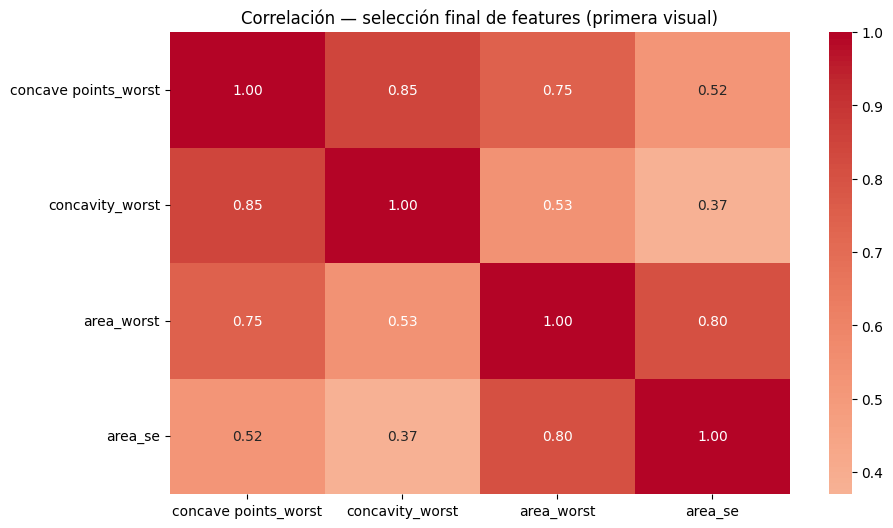

In [39]:
plt.figure(figsize=(10,6))
sns.heatmap(
    X_train[features_final_primera].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    center=0
)
plt.title("Correlación — selección final de features (primera visual)")
plt.show()


### Ejercicio 8

Evalúa tu primer feature reduction. Entrena un modelo y evalúa su perfomance con los features que seleccionaste en el ejercicio anterios (emplea la validación cruzada)

In [40]:
X_train_reduced = X_train[features_final_primera]
X_test_reduced = X_test[features_final_primera]


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf_reduced = RandomForestClassifier(max_depth=5, random_state=42)

scores_reduced = cross_val_score(
    rf_reduced,
    X_train_reduced,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

print("Balanced Accuracy CV (train) con features reducidas:", scores_reduced.mean())


Balanced Accuracy CV (train) con features reducidas: 0.9365841073271411


### Ejercicio 9

Prueba ahora a hacer una feature selection utilizando ANOVA. Compara la validación cruzada con la del modelo baseline y con la del modelo anterior. (Pista: SelectKbest)

In [43]:
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Seleccionamos TODAS las features numéricas (como en el baseline)
X_train_full = X_train  # ya contiene todas las columnas numéricas
y_train_full = y_train

# 2. Creamos el selector ANOVA con k=10 (puedes cambiarlo)
selector = SelectKBest(score_func=f_classif, k=10)

# 3. Ajustamos y transformamos
X_train_kbest_np = selector.fit_transform(X_train_full, y_train_full)

# 4. Convertimos a DataFrame con nombres de columnas
X_train_kbest = pd.DataFrame(
    X_train_kbest_np,
    columns=selector.get_feature_names_out()
)

X_train_kbest


,radius_mean,perimeter_mean,area_mean,concavity_mean,concave points_mean,radius_worst,perimeter_worst,area_worst,concavity_worst,concave points_worst
0,16.02,102.70,797.8,0.03299,0.03323,19.19,123.80,1150.0,0.14590,0.09975
1,12.32,78.85,464.1,0.03987,0.03700,13.50,86.97,549.1,0.12420,0.09391
2,12.85,82.63,514.5,0.06126,0.01867,14.40,91.63,645.8,0.18380,0.05601
3,14.90,102.10,685.0,0.27330,0.09711,16.35,125.40,832.7,0.90190,0.24750
4,18.61,122.10,1094.0,0.14900,0.07731,21.31,139.90,1403.0,0.34460,0.14900
...,...,...,...,...,...,...,...,...,...,...
450,13.03,82.61,523.8,0.02562,0.02923,13.30,84.46,545.9,0.04833,0.05013
451,11.89,76.39,433.8,0.02555,0.02179,13.05,85.09,522.9,0.11640,0.08263
452,13.00,82.61,520.2,0.01206,0.01762,14.34,91.06,628.5,0.04462,0.05921
453,14.20,92.41,618.4,0.05063,0.03058,16.45,112.10,828.5,0.25120,0.13390


In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf_anova = RandomForestClassifier(max_depth=5, random_state=42)

scores_anova = cross_val_score(
    rf_anova,
    X_train_kbest,
    y_train_full,
    cv=5,
    scoring="balanced_accuracy"
)

print("Balanced Accuracy CV (train) con ANOVA:", scores_anova.mean())


Balanced Accuracy CV (train) con ANOVA: 0.9336429308565531


### Ejercicio 10

Prueba a hacer ahora una selección de features con RFE (Recursive Feature Elimination), hasta quedarte con 5 features. Evalúa perfomance en "balanced_accuracy" con cross_validation y compara con la baseline.

In [47]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Modelo base para RFE
rf_RFE = RandomForestClassifier(random_state=42)

# RFE para quedarnos con 5 features
rfe = RFE(
    estimator=rf_RFE,
    n_features_to_select=5,
    step=1
)

rfe.fit(X_train, y_train)

# Ranking de features
ranking_df = pd.DataFrame(
    rfe.ranking_,
    columns=["ranking"],
    index=X_train.columns
).sort_values("ranking")

print(ranking_df)

# Features seleccionadas
selected_features_rfe = ranking_df[ranking_df["ranking"] == 1].index.tolist()
print("\nFeatures seleccionadas por RFE:")
print(selected_features_rfe)


                         ranking
concave points_mean            1
radius_worst                   1
area_worst                     1
perimeter_worst                1
concave points_worst           1
radius_mean                    2
concavity_mean                 3
texture_worst                  4
area_mean                      5
perimeter_mean                 6
symmetry_worst                 7
concavity_worst                8
texture_mean                   9
area_se                       10
smoothness_worst              11
compactness_worst             12
perimeter_se                  13
compactness_mean              14
smoothness_mean               15
radius_se                     16
fractal_dimension_worst       17
fractal_dimension_se          18
compactness_se                19
texture_se                    20
concavity_se                  21
concave points_se             22
symmetry_se                   23
symmetry_mean                 24
fractal_dimension_mean        25
smoothness

In [48]:
from sklearn.model_selection import cross_val_score

X_train_rfe = X_train[selected_features_rfe]

rf_model_rfe = RandomForestClassifier(max_depth=5, random_state=42)

scores_rfe = cross_val_score(
    rf_model_rfe,
    X_train_rfe,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

print("Balanced Accuracy CV (train) con RFE:", scores_rfe.mean())


Balanced Accuracy CV (train) con RFE: 0.9353973168214654


### Ejercicio 11

Prueba a eliminar features con el modelo de RandomForestClassifier (emplea SelectFromModel de sklearn). Utiliza esta vez una regresión logística para entrenar con las features escogidas y compara con el baseline. Muestra primero la importancia obtenida con el modelo baseline (que básicamente es el mismo que vamos a usar con SelectFromModel). Prueba primero para features por encima de la mediana y luego para las 5 primeras.

In [49]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Modelo baseline
rf_base = RandomForestClassifier(max_depth=5, random_state=42)
rf_base.fit(X_train, y_train)

# Importancias
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_base.feature_importances_
}).sort_values("importance", ascending=False)

importances


,feature,importance
23,area_worst,0.152915
27,concave points_worst,0.134546
20,radius_worst,0.100371
22,perimeter_worst,0.087629
7,concave points_mean,0.083709
2,perimeter_mean,0.077532
0,radius_mean,0.059437
6,concavity_mean,0.051643
3,area_mean,0.044947
26,concavity_worst,0.030722


In [50]:
from sklearn.feature_selection import SelectFromModel

# Umbral = mediana de importancias
median_importance = importances["importance"].median()

selector_median = SelectFromModel(
    estimator=rf_base,
    threshold=median_importance,
    prefit=True
)

selected_features_median = X_train.columns[selector_median.get_support()]
print("Features seleccionadas (importancia > mediana):")
print(selected_features_median)


Features seleccionadas (importancia > mediana):
Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'concavity_mean', 'concave points_mean', 'radius_se', 'area_se',
       'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst'],
      dtype='str')


In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Escalado
scaler = StandardScaler()
X_train_median_scaled = scaler.fit_transform(X_train[selected_features_median])

# Modelo
log_reg_median = LogisticRegression(max_iter=5000)

# Validación cruzada
scores_median = cross_val_score(
    log_reg_median,
    X_train_median_scaled,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

print("Balanced Accuracy CV (train) SelectFromModel (mediana):", scores_median.mean())


Balanced Accuracy CV (train) SelectFromModel (mediana): 0.9583075335397317


In [53]:
from sklearn.feature_selection import SelectFromModel

# Umbral = mediana de importancias
median_importance = importances["importance"].mean()

selector_mean = SelectFromModel(
    estimator=rf_base,
    threshold=median_importance,
    prefit=True
)

selected_features_mean = X_train.columns[selector_mean.get_support()]
print("Features seleccionadas (importancia > media):")
print(selected_features_mean)

Features seleccionadas (importancia > media):
Index(['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean',
       'concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst',
       'concave points_worst'],
      dtype='str')


In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Escalado
scaler = StandardScaler()
X_train_mean_scaled = scaler.fit_transform(X_train[selected_features_mean])

# Modelo
log_reg_mean = LogisticRegression(max_iter=5000)

# Validación cruzada
scores_mean = cross_val_score(
    log_reg_mean,
    X_train_mean_scaled,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

print("Balanced Accuracy CV (train) SelectFromModel (media):", scores_mean.mean())

Balanced Accuracy CV (train) SelectFromModel (media): 0.9400928792569658


### Ejercicio EXTRA:

Investiga RFECV y obten el número optimo de features siguiendo esta técnica pero con el "balanced_accuracy" como métrica.